<a href="https://colab.research.google.com/github/padmasri2005/Zomato_Data_Analysis/blob/main/Zomato_Restuarants_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ZOMATO BANGALORE DATA ANALYSIS**

**Objective:**

To perform Exploratory Data Analysis (EDA) on the Zomato Bangalore dataset and generate meaningful business insights using Python.

In [421]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [422]:
# Lodading the data
df = pd.read_excel("/content/zomato_rest_data.xlsx")

**Task 1: Data Understanding & Cleaning**

1. Dataset Exploration

In [423]:
# Display first 5 rows
df.head()

,Unnamed: 0,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [424]:
# Display shape of dataset (rows and columns)
df.shape

(51717, 18)

In [425]:
# List column names
list(df.columns)

['Unnamed: 0',
 'url',
 'address',
 'name',
 'online_order',
 'book_table',
 'rate',
 'votes',
 'phone',
 'location',
 'rest_type',
 'dish_liked',
 'cuisines',
 'approx_cost(for two people)',
 'reviews_list',
 'menu_item',
 'listed_in(type)',
 'listed_in(city)']

In [426]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Unnamed: 0                   51717 non-null  int64 
 1   url                          51717 non-null  object
 2   address                      51717 non-null  object
 3   name                         51717 non-null  object
 4   online_order                 51717 non-null  object
 5   book_table                   51717 non-null  object
 6   rate                         43942 non-null  object
 7   votes                        51717 non-null  int64 
 8   phone                        50509 non-null  object
 9   location                     51696 non-null  object
 10  rest_type                    51490 non-null  object
 11  dish_liked                   23639 non-null  object
 12  cuisines                     51672 non-null  object
 13  approx_cost(for two people)  51

In [427]:
# Identify missing values
df.isnull().sum()

,0
Unnamed: 0,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21


2. Data Cleaning

In [428]:
# Remove duplicate records
df.drop_duplicates(inplace = True)
df.shape # no duplicate values present in the data

(51717, 18)

In [429]:
# dropping unwanted columns
df = df.drop(["url","phone","Unnamed: 0","address","location","reviews_list","menu_item","rest_type"],axis = 1)

In [430]:
# Renaming columns
d = {"listed_in(city)" : "location","listed_in(type)" : "rest_type","approx_cost(for two people)" : "cost_for_two"}
df.rename(columns = d,inplace = True)


In [431]:

# handling missing values in rate column and changing datatype

# 1)replace "NEW" with nan in rating column
df['rate'] = df['rate'].replace("NEW",np.nan)

# 2)replace "-" with nan in rating column
df['rate'] = df['rate'].replace("-",np.nan)

# 3) Remove the "/5" to convert the col to float
df['rate'] = df['rate'].str.strip("/5")

#4) coverting the col to float data type
df['rate'] = df['rate'].astype(float)

# 5) filling the null values with the mean of the col
df['rate'] = df['rate'].fillna(round(df['rate'].mean()))

In [432]:
# Handling missing values in 'cost_for_two' column and converting datatype

# 1) Checking unique values in the column
df['cost_for_two'].unique()

# 2) Removing commas from the cost values
df['cost_for_two'] = df['cost_for_two'].str.replace(",", "")

# 3) Converting the column from object to float datatype
df['cost_for_two'] = df['cost_for_two'].astype(float)

# 4) Filling missing values with the mean cost (rounded)
df['cost_for_two'] = df['cost_for_two'].fillna(round(df['cost_for_two'].mean()))

# 5) Converting the column to integer datatype for cleaner representation
df['cost_for_two'] = df['cost_for_two'].astype(int)

In [433]:
# Handling missing values in 'dish_liked' column

# 1) Checking the most frequently occurring dish (mode)
df['dish_liked'].mode()

# 2) Checking unique values in the column
df['dish_liked'].unique()

# 3) Filling missing values with the most frequently liked dish
df['dish_liked'] = df['dish_liked'].fillna(df['dish_liked'].mode()[0])

In [434]:
# Handling missing values in 'cuisines' column

# Check most frequent cuisine
df['cuisines'].mode()

# Check unique cuisine values
df['cuisines'].unique()

# Fill missing values with most frequent cuisine
df['cuisines'] = df['cuisines'].fillna(df['cuisines'].mode()[0])

In [435]:
# Checking number of missing values in each column
df.isnull().sum()

,0
name,0
online_order,0
book_table,0
rate,0
votes,0
dish_liked,0
cuisines,0
cost_for_two,0
rest_type,0
location,0


In [436]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   name          51717 non-null  object 
 1   online_order  51717 non-null  object 
 2   book_table    51717 non-null  object 
 3   rate          51717 non-null  float64
 4   votes         51717 non-null  int64  
 5   dish_liked    51717 non-null  object 
 6   cuisines      51717 non-null  object 
 7   cost_for_two  51717 non-null  int64  
 8   rest_type     51717 non-null  object 
 9   location      51717 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 3.9+ MB


**Task 2: Univariate Analysis**

Perform the following analysis with proper visualizations:
1. Top 5 locations with highest number of restaurants
2. Distribution of restaurant ratings
3. Percentage of restaurants offering online orders
4. Distribution of average cost for two

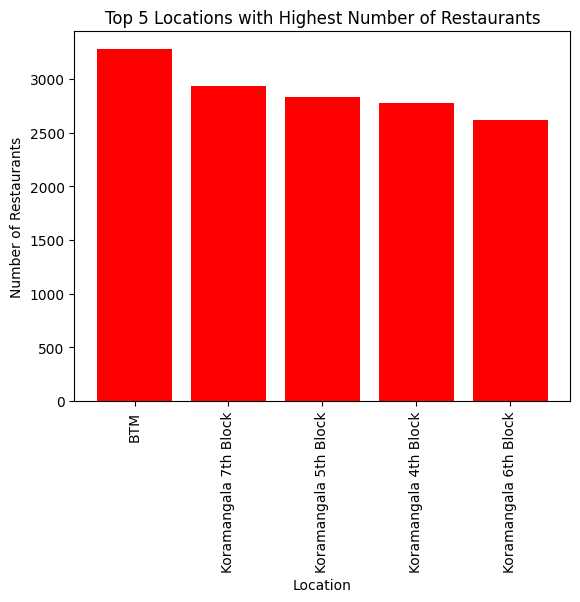

In [437]:
# Counting number of restaurants in each location
top5 = df['location'].value_counts().head()

# Creating a bar chart to visualize top 5 locations
plt.bar(top5.index, top5.values, color="red")

# Adding title to the chart
plt.title("Top 5 Locations with Highest Number of Restaurants")

# Labeling X and Y axes
plt.xlabel("Location")
plt.ylabel("Number of Restaurants")

# Rotating x-axis labels for better readability
plt.xticks(rotation=90)

# Displaying the plot
plt.show()

The top 5 locations with the highest number of restaurants are BTM, Koramangala 7th Block, Koramangala 5th Block, Koramangala 4th Block, and Koramangala 6th Block



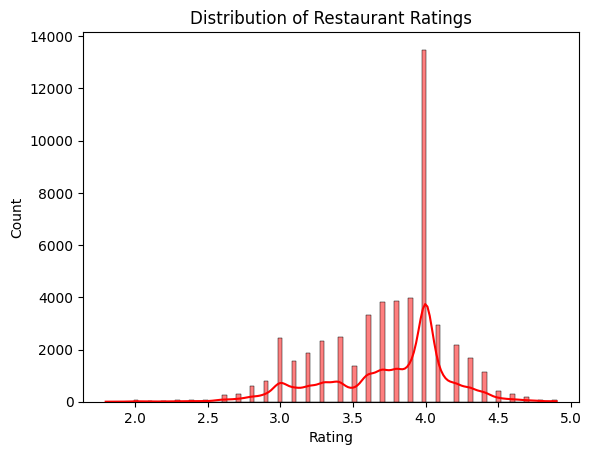

In [438]:
# Distribution of restaurant ratings

# Ploting histogram with KDE curve
sns.histplot(df['rate'], kde=True,color = "red")

# Adding title and labels
plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

# Displaying the plot
plt.show()

Most restaurants have ratings close to 4, indicating overall positive customer feedback.

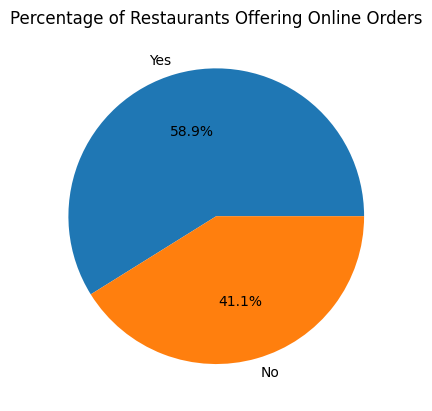

In [439]:
# Percentage of restaurants offering online orders

# Counting Yes and No values in online_order column
online_counts = df['online_order'].value_counts()

# Creating pie chart
plt.pie(online_counts.values, labels=online_counts.index, autopct="%0.1f%%")

# Adding title
plt.title("Percentage of Restaurants Offering Online Orders")

# Displaying plot
plt.show()

Most restaurants (58.9%) offer online ordering, showing strong adoption of digital services.

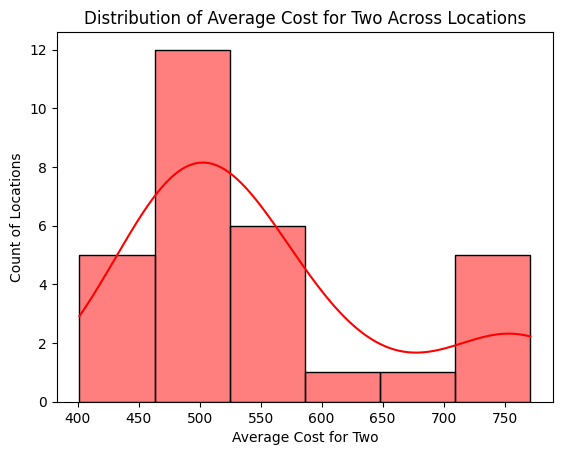

In [440]:
# Calculating average cost for two across each location
df1 = df.groupby('location')['cost_for_two'].mean()

# Creating histogram to show distribution of average cost values
sns.histplot(df1, kde=True, color="red")

# Adding title and axis labels
plt.title("Distribution of Average Cost for Two Across Locations")
plt.xlabel("Average Cost for Two")
plt.ylabel("Count of Locations")

# Displaying the plot
plt.show()

Most locations have an average cost for two between ₹450 and ₹550, indicating that the majority of restaurants fall within a moderate price range.

**Task 3: Bivariate Analysis**

Analyze the relationship between:
* Rating vs Cost
* Rating vs Online Order
* Votes vs Rating

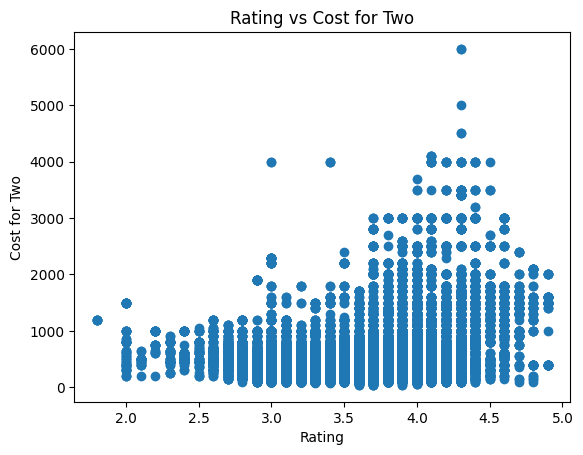

In [441]:
# Rating vs Cost
plt.scatter(y=df['cost_for_two'], x=df['rate'])

# Adding title and labels
plt.title("Rating vs Cost for Two")
plt.xlabel("Rating")
plt.ylabel("Cost for Two")

# Displaying the plot
plt.show()

There is a slight positive relationship between rating and cost, but higher cost does not consistently guarantee higher ratings.

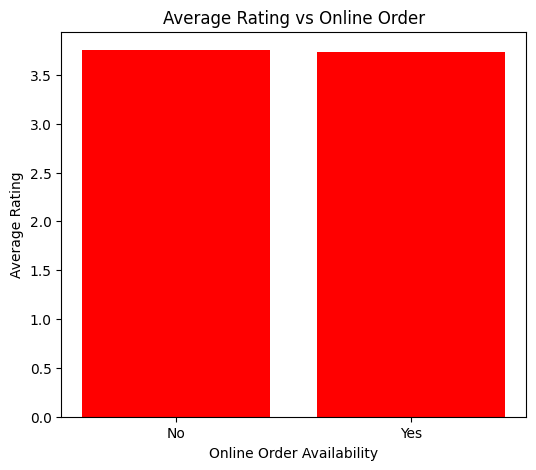

In [442]:
# Group by online_order and calculate average rating
data = df.groupby('online_order')['rate'].mean().reset_index()

# Create figure
plt.figure(figsize=(6,5))

# Create bar graph
plt.bar(data['online_order'], data['rate'], color='red')

# Add title and labels
plt.title("Average Rating vs Online Order")
plt.xlabel("Online Order Availability")
plt.ylabel("Average Rating")

# Display plot
plt.show()

No, the ratings are nearly the same for restaurants with and without online ordering, indicating that offering online services does not significantly impact customer ratings.

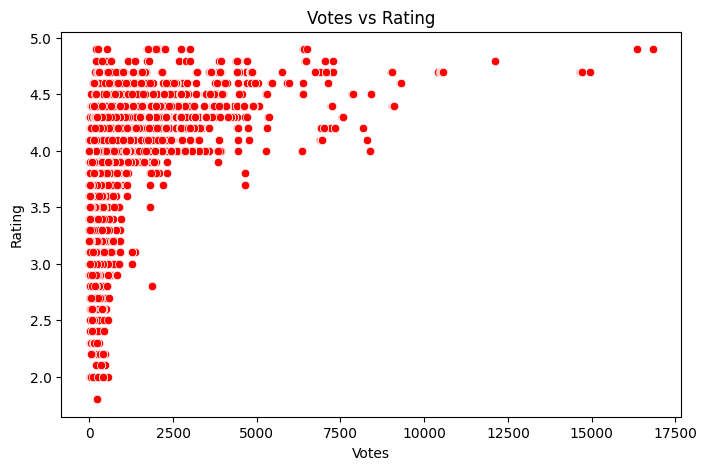

In [443]:
# Create a new figure with specified size
plt.figure(figsize=(8,5))

# Create scatter plot to show relationship between votes and rating
sns.scatterplot(x='votes', y='rate', data=df, color='red')

# Add title
plt.title("Votes vs Rating")

# Label axes
plt.xlabel("Votes")
plt.ylabel("Rating")

# Display the plot
plt.show()

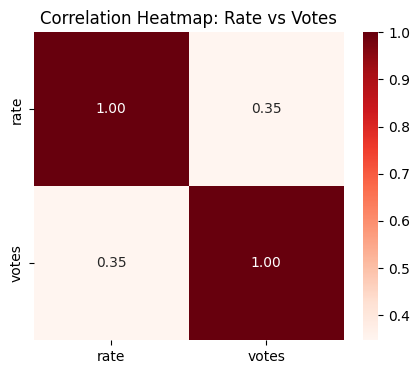

In [444]:
# Selecting only rate and votes columns
corr_data = df[['rate', 'votes']]

# Calculating correlation matrix
corr_matrix = corr_data.corr()

plt.figure(figsize=(5,4))

# Creating heatmap
sns.heatmap(corr_matrix, annot=True, cmap='Reds', fmt=".2f")

# Adding title
plt.title("Correlation Heatmap: Rate vs Votes")

plt.show()

There is no strong relationship between votes and ratings, as high and low ratings are observed across different vote counts. This indicates that the number of votes does not directly determine the rating of a restaurant.

In [445]:
bottom5 = df['location'].value_counts().tail()
bottom5

,count
location,
Frazer Town,1185
Malleshwaram,1096
Rajajinagar,1079
Banashankari,863
New BEL Road,740


# **Task 4: Business Insights & Recommendations**
**Does higher cost lead to higher ratings?**

Yes, as the cost increases, restaurant ratings tend to increase slightly.

**Does offering online order impact ratings?**

No, the ratings are nearly the same for restaurants with and without online ordering, indicating that offering online services does not significantly impact customer ratings.

**Which location appears highly competitive?**

BTM is more competitive , because its having more number of restraunts

**Where would you recommend opening a new restaurant?**

new bel road,banashankari,rajajinagar ,these three would be great because they have low competition.

In [446]:
df.to_csv("cleaned_dataset")